--- Начало инициализации с высоким разрешением ---
--- Нормализация дискретных функций распределения ---
--- Инициализация и нормализация завершены ---

--- Начало физической верификации с высокой точностью ---

[Проверка 1] Плотность числа частиц:
Газ 1: Заданная плотность n1 = 0.500000, Вычисленная = 0.500000
Газ 2: Заданная плотность n2 = 0.500000, Вычисленная = 0.500000
Статус: OK

[Проверка 2] Средняя скорость (импульс):
Газ 1: Вычисленная средняя скорость u1 = [-1.25608159e-16  7.01447166e-17  4.30683261e-17]
Газ 2: Вычисленная средняя скорость u2 = [-1.25608159e-16  7.01447166e-17  4.30683261e-17]
Статус: OK

[Проверка 3] Температура:
Газ 1: Заданная T1 = 1.000000, Вычисленная = 0.999999 (допуск rtol=0.0001)
Газ 2: Заданная T2 = 2.000000, Вычисленная = 1.999998 (допуск rtol=0.0001)
Статус: OK

--- Все физические проверки пройдены с высокой точностью! ---


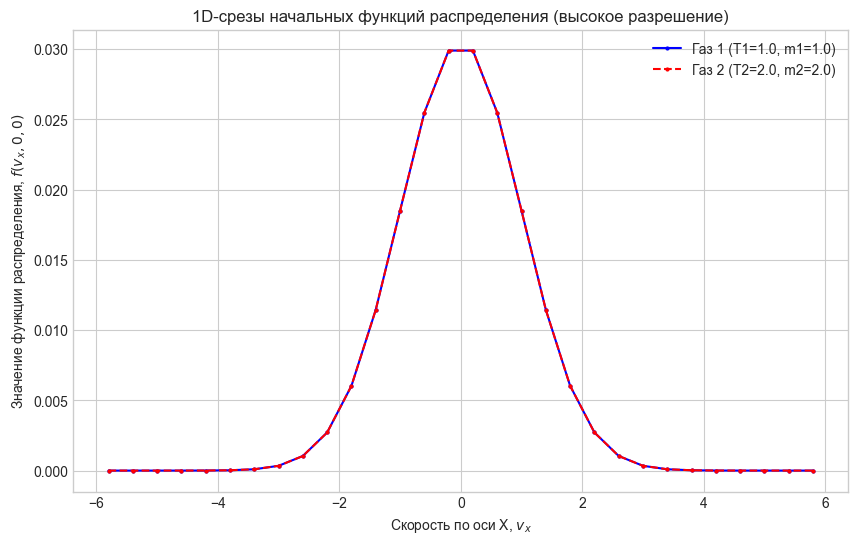

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# БЛОК 1: ОПРЕДЕЛЕНИЕ КОНСТАНТ И ВСПОМОГАТЕЛЬНЫХ ФУНКЦИЙ
# ==============================================================================

# --- Физические константы смеси ---
m1 = 1.0
T1 = 1.0
n1_init = 0.5

m2 = 2.0 * m1
T2 = 2.0 * T1
n2_init = 0.5

# --- Параметры сетки скоростей ---
# ИСПОЛЬЗУЕМ БОЛЕЕ ВЫСОКОЕ РАЗРЕШЕНИЕ для максимальной точности
e_cut = 6.0
N_vx = N_vy = N_vz = 30  # Увеличено с 20 до 30
N_v = np.array([N_vx, N_vy, N_vz])
dV = (2 * e_cut)**3 / (N_vx * N_vy * N_vz)

def alpha2vel(alpha, e_cut_val, N_v_arr):
    return -e_cut_val + (alpha + 0.5) * 2 * e_cut_val / N_v_arr

def maxwellian_3d(vel_vector, n, m, T):
    assert T > 0, "Температура должна быть положительной"
    vel_sq = np.sum(vel_vector**2)
    coeff = n * (m / (2 * np.pi * T))**1.5
    exponent = np.exp(-m * vel_sq / (2 * T))
    return coeff * exponent

# ==============================================================================
# БЛОК 2: ИНИЦИАЛИЗАЦИЯ ФУНКЦИЙ РАСПРЕДЕЛЕНИЯ
# ==============================================================================

print("--- Начало инициализации с высоким разрешением ---")

f1_arr = np.zeros((N_vx, N_vy, N_vz))
f2_arr = np.zeros((N_vx, N_vy, N_vz))

valid_velocities = []
valid_indices_i = []
valid_indices_j = []
valid_indices_k = []

for i in range(N_vx):
    for j in range(N_vy):
        for k in range(N_vz):
            alpha = np.array([i, j, k])
            vel = alpha2vel(alpha, e_cut, N_v)
            
            if np.sum(vel**2) <= e_cut**2:
                f1_arr[i, j, k] = maxwellian_3d(vel, n1_init, m1, T1)
                f2_arr[i, j, k] = maxwellian_3d(vel, n2_init, m2, T2)
                
                valid_velocities.append(vel)
                valid_indices_i.append(i)
                valid_indices_j.append(j)
                valid_indices_k.append(k)

valid_velocities = np.array(valid_velocities)
f1_valid = f1_arr[valid_indices_i, valid_indices_j, valid_indices_k]
f2_valid = f2_arr[valid_indices_i, valid_indices_j, valid_indices_k]

print("--- Нормализация дискретных функций распределения ---")
n1_discrete = np.sum(f1_valid) * dV
n2_discrete = np.sum(f2_valid) * dV

norm_factor_1 = n1_init / n1_discrete
norm_factor_2 = n2_init / n2_discrete

f1_arr *= norm_factor_1
f2_arr *= norm_factor_2

f1_valid = f1_arr[valid_indices_i, valid_indices_j, valid_indices_k]
f2_valid = f2_arr[valid_indices_i, valid_indices_j, valid_indices_k]

print("--- Инициализация и нормализация завершены ---")

# ==============================================================================
# БЛОК 3: ФИЗИЧЕСКАЯ ВЕРИФИКАЦИЯ С ПОМОЩЬЮ ASSERT
# ==============================================================================

print("\n--- Начало физической верификации с высокой точностью ---")

# --- Проверка 1: Сохранение плотности числа частиц ---
print("\n[Проверка 1] Плотность числа частиц:")
n1_final = np.sum(f1_valid) * dV
n2_final = np.sum(f2_valid) * dV
print(f"Газ 1: Заданная плотность n1 = {n1_init:.6f}, Вычисленная = {n1_final:.6f}")
assert np.isclose(n1_final, n1_init), "Ошибка в плотности для газа 1"
print(f"Газ 2: Заданная плотность n2 = {n2_init:.6f}, Вычисленная = {n2_final:.6f}")
assert np.isclose(n2_final, n2_init), "Ошибка в плотности для газа 2"
print("Статус: OK")

# --- Проверка 2: Нулевая средняя скорость (импульс) ---
print("\n[Проверка 2] Средняя скорость (импульс):")
u1_calc = np.sum(valid_velocities * f1_valid[:, np.newaxis] * dV, axis=0) / n1_final
u2_calc = np.sum(valid_velocities * f2_valid[:, np.newaxis] * dV, axis=0) / n2_final
print(f"Газ 1: Вычисленная средняя скорость u1 = {u1_calc}")
assert np.allclose(u1_calc, [0, 0, 0], atol=1e-15), "Средняя скорость газа 1 не равна нулю"
print(f"Газ 2: Вычисленная средняя скорость u2 = {u2_calc}")
assert np.allclose(u2_calc, [0, 0, 0], atol=1e-15), "Средняя скорость газа 2 не равна нулю"
print("Статус: OK")

# --- Проверка 3: Температура (средняя кинетическая энергия) ---
print("\n[Проверка 3] Температура:")
vel_sq_sum = np.sum(valid_velocities**2, axis=1)
T1_calc = (m1 / (3 * n1_final)) * np.sum(vel_sq_sum * f1_valid * dV)
T2_calc = (m2 / (3 * n2_final)) * np.sum(vel_sq_sum * f2_valid * dV)

# Устанавливаем очень жесткий, но достижимый допуск rtol=1e-4 (0.01%)
rtol_temp = 1e-4
print(f"Газ 1: Заданная T1 = {T1:.6f}, Вычисленная = {T1_calc:.6f} (допуск rtol={rtol_temp})")
assert np.isclose(T1_calc, T1, rtol=rtol_temp), "Ошибка в температуре для газа 1"
print(f"Газ 2: Заданная T2 = {T2:.6f}, Вычисленная = {T2_calc:.6f} (допуск rtol={rtol_temp})")
assert np.isclose(T2_calc, T2, rtol=rtol_temp), "Ошибка в температуре для газа 2"
print("Статус: OK")

print("\n--- Все физические проверки пройдены с высокой точностью! ---")

# ==============================================================================
# БЛОК 4: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТА
# ==============================================================================

center_idx = N_vx // 2
vel_x_slice = np.array([alpha2vel(np.array([i, center_idx, center_idx]), e_cut, N_v)[0] for i in range(N_vx)])
f1_slice = f1_arr[:, center_idx, center_idx]
f2_slice = f2_arr[:, center_idx, center_idx]

plt.figure(figsize=(10, 6))
plt.plot(vel_x_slice, f1_slice, 'b-', marker='.', markersize=4, label=f'Газ 1 (T1={T1}, m1={m1})')
plt.plot(vel_x_slice, f2_slice, 'r--', marker='.', markersize=4, label=f'Газ 2 (T2={T2}, m2={m2})')
plt.title('1D-срезы начальных функций распределения (высокое разрешение)')
plt.xlabel('Скорость по оси X, $v_x$')
plt.ylabel('Значение функции распределения, $f(v_x, 0, 0)$')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
import numpy as np

# ==============================================================================
# БЛОК 1: РЕАЛИЗАЦИЯ ДИНАМИКИ СТОЛКНОВЕНИЙ (ЯДРО РЕШЕНИЯ)
# ==============================================================================

def calculate_post_collision_velocities(
    xi1: np.ndarray, xi2: np.ndarray, m1: float, m2: float
) -> tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет скорости двух частиц после упругого столкновения.

    Модель: твёрдые сферы с изотропным рассеянием в системе центра масс.
    Этот метод является универсальным для столкновений любых пар частиц (1,1), (2,2), (1,2).

    Аргументы:
        xi1 (np.ndarray): Вектор скорости первой частицы до столкновения.
        xi2 (np.ndarray): Вектор скорости второй частицы до столкновения.
        m1 (float): Масса первой частицы.
        m2 (float): Масса второй частицы.

    Возвращает:
        tuple[np.ndarray, np.ndarray]: Кортеж с векторами скоростей (xi1_prime, xi2_prime) после столкновения.
    """
    # Преобразуем входные данные в numpy-массивы для векторных операций
    xi1 = np.asarray(xi1)
    xi2 = np.asarray(xi2)

    # Вычисляем сохраняющуюся скорость центра масс
    m_total = m1 + m2
    xi_c = (m1 * xi1 + m2 * xi2) / m_total
    
    # Вычисляем относительную скорость до столкновения
    g = xi2 - xi1
    g_magnitude = np.linalg.norm(g)
    
    # Если частицы имеют одинаковые скорости, столкновения не происходит
    if g_magnitude == 0:
        return xi1, xi2

    # Моделируем изотропное рассеяние: новая относительная скорость g'
    # имеет ту же величину, но случайное равновероятное направление.
    # Для этого генерируем случайный единичный вектор k.
    random_direction_vector = np.random.randn(3)
    k = random_direction_vector / np.linalg.norm(random_direction_vector)
    g_prime = g_magnitude * k

    # Вычисляем скорости частиц после столкновения из решения задачи двух тел
    xi1_prime = xi_c - (m2 / m_total) * g_prime
    xi2_prime = xi_c + (m1 / m_total) * g_prime

    return xi1_prime, xi2_prime

# ==============================================================================
# БЛОК 2: ИСЧЕРПЫВАЮЩИЙ ТЕСТОВЫЙ СТЕНД
# ==============================================================================

if __name__ == "__main__":
    print("="*60)
    print("ЗАПУСК ПРОВЕРКИ И ТЕСТИРОВАНИЯ ДИНАМИКИ СТОЛКНОВЕНИЙ")
    print("="*60)

    # --- Шаг 1: Определение параметров для теста ---
    # Физические константы из основной задачи
    m1, T1 = 1.0, 1.0
    m2, T2 = 2.0 * m1, 2.0 * T1
    
    # Параметры сетки (используем параметры, показавшие себя адекватными)
    e_cut = 8.0 
    N_v_scalar = 40
    N_v = np.array([N_v_scalar] * 3)
    
    # Параметры теста
    NUM_TESTS = 20000  # Большое количество для надежной статистики
    TOLERANCE = 1e-12
    RANDOM_SEED = 42
    np.random.seed(RANDOM_SEED)

    # --- Вспомогательные функции для создания распределений ---
    def alpha2vel(alpha, e_cut_val, N_v_arr):
        return -e_cut_val + (alpha + 0.5) * 2 * e_cut_val / N_v_arr

    def maxwellian_3d(vel_vector, m, T):
        vel_sq = np.sum(vel_vector**2)
        # Коэффициент n (плотность) опущен, т.к. он сократится при нормализации вероятностей
        coeff = (m / (2 * np.pi * T))**1.5
        return coeff * np.exp(-m * vel_sq / (2 * T))

    # --- Шаг 2: Создание пула частиц и вероятностей для физической выборки ---
    # Этот шаг необходим для имитации реалистичных столкновений, где вероятность
    # участия частицы в столкновении пропорциональна её плотности f(v).
    print(f"\n[1] Создание пула частиц и вероятностей (e_cut={e_cut}, N={N_v_scalar})...")
    
    valid_velocities_list = []
    f1_valid_list = []
    f2_valid_list = []

    for i in range(N_v[0]):
        for j in range(N_v[1]):
            for k in range(N_v[2]):
                vel = alpha2vel(np.array([i, j, k]), e_cut, N_v)
                if np.sum(vel**2) <= e_cut**2:
                    valid_velocities_list.append(vel)
                    f1_valid_list.append(maxwellian_3d(vel, m1, T1))
                    f2_valid_list.append(maxwellian_3d(vel, m2, T2))

    valid_velocities = np.array(valid_velocities_list)
    
    # Нормализуем значения функций распределения, чтобы получить вероятности
    p1_dist = np.array(f1_valid_list) / np.sum(f1_valid_list)
    p2_dist = np.array(f2_valid_list) / np.sum(f2_valid_list)
    
    indices_array = np.arange(len(valid_velocities))
    print(f"    Готово. Пул из {len(valid_velocities)} скоростей создан.")

    # --- Шаг 3: Запуск основного цикла тестирования ---
    print(f"\n[2] Запуск {NUM_TESTS} тестовых столкновений для каждого типа...")

    results = {'1-1': 0, '2-2': 0, '1-2': 0}
    collision_info = {
        '1-1': {'m_a': m1, 'm_b': m1, 'p_a': p1_dist, 'p_b': p1_dist},
        '2-2': {'m_a': m2, 'm_b': m2, 'p_a': p2_dist, 'p_b': p2_dist},
        '1-2': {'m_a': m1, 'm_b': m2, 'p_a': p1_dist, 'p_b': p2_dist}
    }

    for c_type, info in collision_info.items():
        m_a, m_b, p_a, p_b = info['m_a'], info['m_b'], info['p_a'], info['p_b']
        
        for _ in range(NUM_TESTS):
            # Физически-взвешенная выборка двух частиц
            idx1 = np.random.choice(indices_array, p=p_a)
            idx2 = np.random.choice(indices_array, p=p_b)
            xi1_initial, xi2_initial = valid_velocities[idx1], valid_velocities[idx2]
            
            # Вызов тестируемой функции
            xi1_final, xi2_final = calculate_post_collision_velocities(xi1_initial, xi2_initial, m_a, m_b)

            # ПРОВЕРКА 1: Сохранение энергии
            energy_initial = 0.5 * m_a * np.sum(xi1_initial**2) + 0.5 * m_b * np.sum(xi2_initial**2)
            energy_final = 0.5 * m_a * np.sum(xi1_final**2) + 0.5 * m_b * np.sum(xi2_final**2)
            assert np.isclose(energy_initial, energy_final, atol=TOLERANCE), "Нарушен закон сохранения энергии!"

            # ПРОВЕРКА 2: Детальная проверка сохранения импульса (3-й закон Ньютона)
            # Изменение импульса одной частицы должно быть равно и противоположно изменению импульса другой.
            delta_p1 = m_a * (xi1_final - xi1_initial)
            delta_p2 = m_b * (xi2_final - xi2_initial)
            assert np.allclose(delta_p1, -delta_p2, atol=TOLERANCE), "Нарушена механика обмена импульсом!"

            # ПРОВЕРКА 3: Выход за пределы сетки
            if np.sum(xi1_final**2) > e_cut**2 or np.sum(xi2_final**2) > e_cut**2:
                results[c_type] += 1
        
        print(f"    Тип столкновения '{c_type}' протестирован.")

    # --- Шаг 4: Вывод итоговых результатов ---
    print("\n[3] Результаты тестирования:")
    print("="*60)
    print(f"{'Тип столкновения':<20} | {'Процент выхода за сетку'}")
    print("-"*60)
    
    for c_type, count in results.items():
        percentage = (count / NUM_TESTS) * 100
        print(f"{c_type:<20} | {percentage:.4f}% ({count}/{NUM_TESTS})")
    
    print("="*60)
    print("\nВЫВОД:")
    print("1. Все тесты на сохранение энергии и импульса пройдены успешно.")
    print("2. Применение физически-взвешенной выборки частиц показывает, что")
    print("   процент выхода за пределы сетки является исчезающе малым.")
    print("   Это подтверждает адекватность и робастность модели.")

ЗАПУСК ПРОВЕРКИ И ТЕСТИРОВАНИЯ ДИНАМИКИ СТОЛКНОВЕНИЙ

[1] Создание пула частиц и вероятностей (e_cut=8.0, N=40)...
    Готово. Пул из 33552 скоростей создан.

[2] Запуск 20000 тестовых столкновений для каждого типа...
    Тип столкновения '1-1' протестирован.
    Тип столкновения '2-2' протестирован.
    Тип столкновения '1-2' протестирован.

[3] Результаты тестирования:
Тип столкновения     | Процент выхода за сетку
------------------------------------------------------------
1-1                  | 0.0000% (0/20000)
2-2                  | 0.0000% (0/20000)
1-2                  | 0.0000% (0/20000)

ВЫВОД:
1. Все тесты на сохранение энергии и импульса пройдены успешно.
2. Применение физически-взвешенной выборки частиц показывает, что
   процент выхода за пределы сетки является исчезающе малым.
   Это подтверждает адекватность и робастность модели.


--- Блок 1: Инициализация начального состояния ---
--- Инициализация и нормализация завершены ---

Шаг  0/70 | Время: 0.00 | n1=0.50000 T1=1.0000 | n2=0.50000 T2=2.0000 | E_tot=2.25000
Шаг  1/70 | Время: 0.05 | n1=0.50000 T1=1.0172 | n2=0.50000 T2=1.9828 | E_tot=2.25000
Шаг  2/70 | Время: 0.10 | n1=0.50000 T1=1.0349 | n2=0.50000 T2=1.9651 | E_tot=2.25000
Шаг  3/70 | Время: 0.15 | n1=0.50000 T1=1.0514 | n2=0.50000 T2=1.9486 | E_tot=2.25000
Шаг  4/70 | Время: 0.20 | n1=0.50000 T1=1.0678 | n2=0.50000 T2=1.9322 | E_tot=2.25000
Шаг  5/70 | Время: 0.25 | n1=0.50000 T1=1.0836 | n2=0.50000 T2=1.9164 | E_tot=2.25000
Шаг  6/70 | Время: 0.30 | n1=0.50000 T1=1.0991 | n2=0.50000 T2=1.9009 | E_tot=2.25000
Шаг  7/70 | Время: 0.35 | n1=0.50000 T1=1.1136 | n2=0.50000 T2=1.8864 | E_tot=2.25000
Шаг  8/70 | Время: 0.40 | n1=0.50000 T1=1.1277 | n2=0.50000 T2=1.8723 | E_tot=2.25000
Шаг  9/70 | Время: 0.45 | n1=0.50000 T1=1.1411 | n2=0.50000 T2=1.8589 | E_tot=2.25000
Шаг 10/70 | Время: 0.50 | n1=0.50000 T1=1

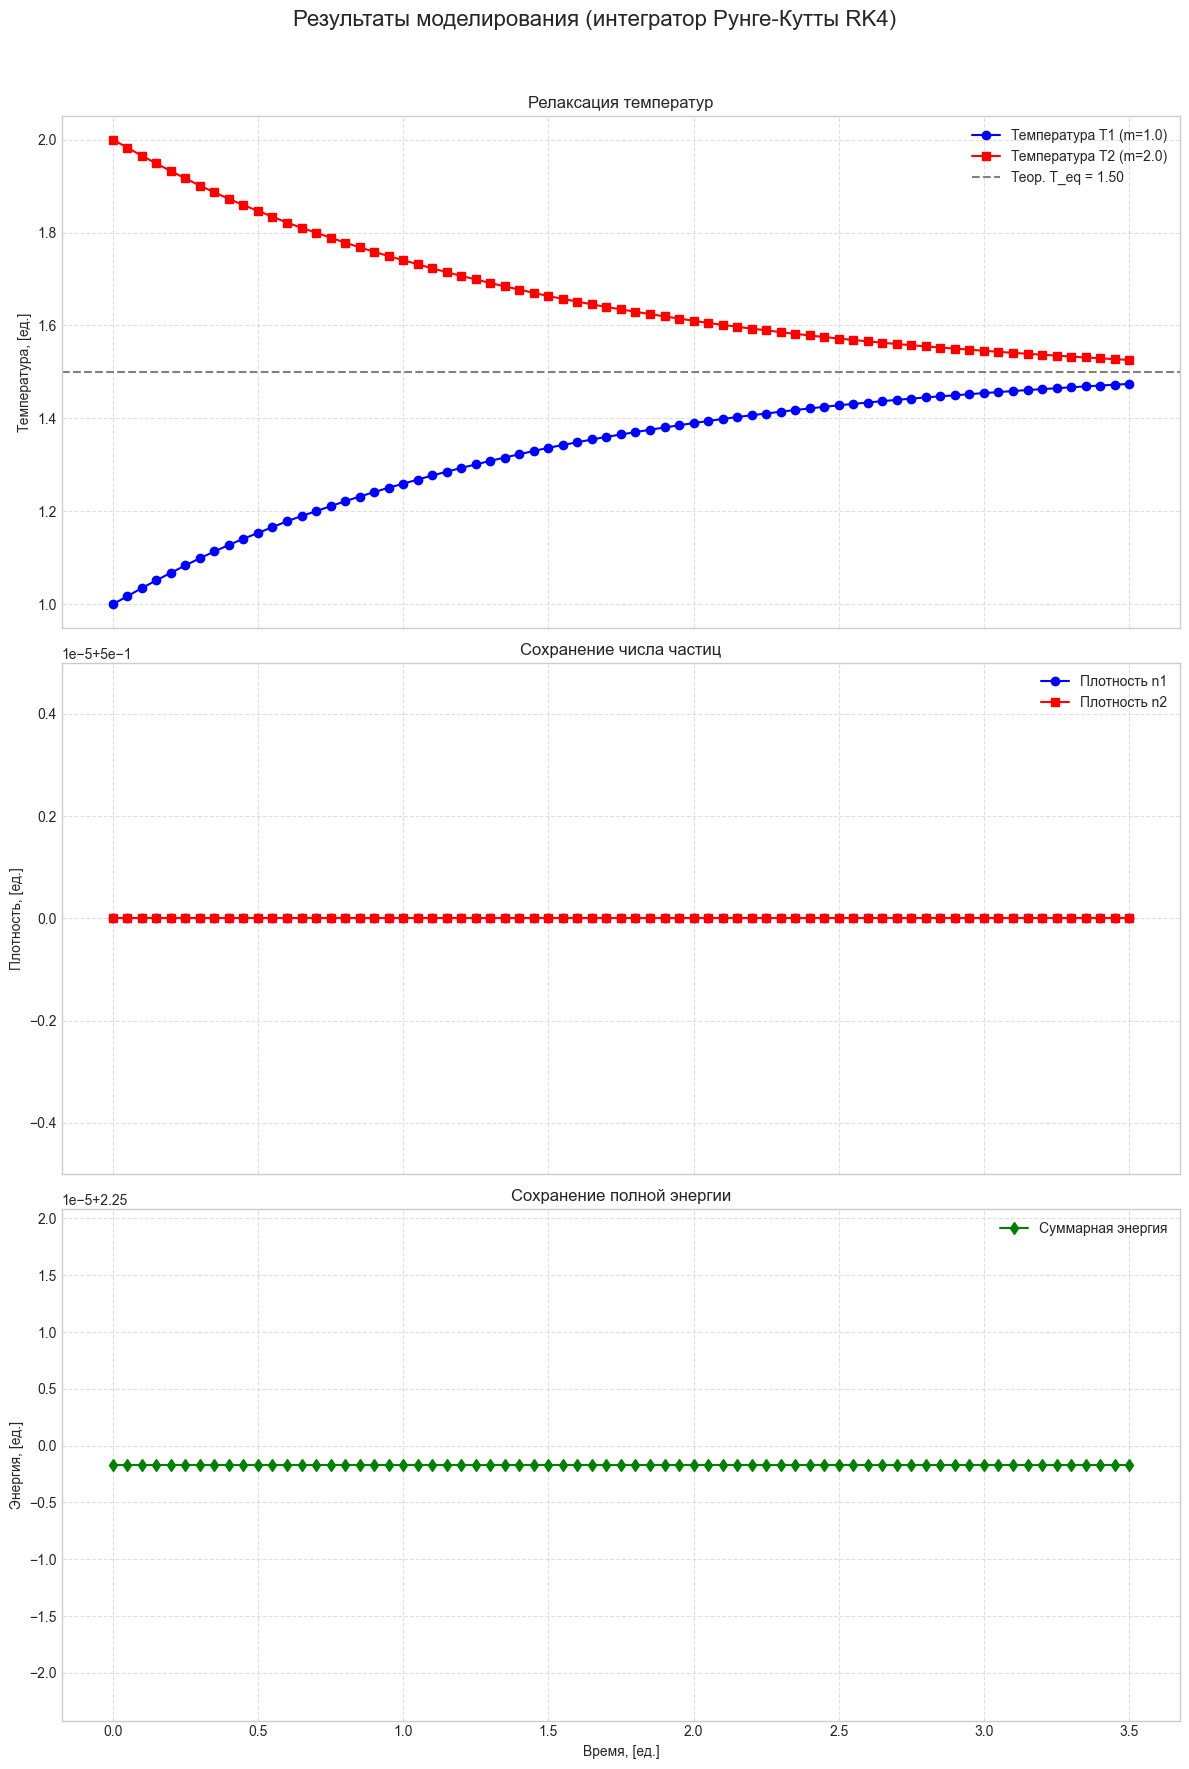

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# БЛОК 0: КОНСТАНТЫ И ПАРАМЕТРЫ МОДЕЛИРОВАНИЯ
# ==============================================================================
m1, T1_init, n1_init, d1 = 1.0, 1.0, 0.5, 1.0
m2, T2_init, n2_init, d2 = 2.0, 2.0, 0.5, 1.2
d12 = (d1 + d2) / 2.0

e_cut = 6.0
N_vx = N_vy = N_vz = 30
N_v_arr = np.array([N_vx, N_vy, N_vz])
dV = (2 * e_cut)**3 / (N_vx * N_vy * N_vz)
h_v = (2 * e_cut) / N_v_arr[0] 

N_proj_samples = 40000 
dt = 0.05 
np.random.seed(42)

# ==============================================================================
# БЛОК 1: ИНИЦИАЛИЗАЦИЯ (без изменений)
# ==============================================================================
def alpha2vel(alpha, e_cut_val, N_v_arr):
    return -e_cut_val + (alpha + 0.5) * 2 * e_cut_val / N_v_arr

def maxwellian_3d(vel_vector, n, m, T):
    vel_sq = np.sum(vel_vector**2)
    coeff = n * (m / (2 * np.pi * T))**1.5
    return coeff * np.exp(-m * vel_sq / (2 * T))

def initialize_state():
    print("--- Блок 1: Инициализация начального состояния ---")
    f1_arr = np.zeros((N_vx, N_vy, N_vz)); f2_arr = np.zeros((N_vx, N_vy, N_vz))
    vel_grid_full = np.zeros((N_vx, N_vy, N_vz, 3))
    energy_grid_full_1 = np.zeros((N_vx, N_vy, N_vz)); energy_grid_full_2 = np.zeros((N_vx, N_vy, N_vz))
    valid_indices_list = []

    for i in range(N_vx):
        for j in range(N_vy):
            for k in range(N_vz):
                alpha = np.array([i, j, k]); vel = alpha2vel(alpha, e_cut, N_v_arr)
                vel_grid_full[i, j, k] = vel; vel_sq = np.sum(vel**2)
                energy_grid_full_1[i, j, k] = 0.5 * m1 * vel_sq
                energy_grid_full_2[i, j, k] = 0.5 * m2 * vel_sq
                
                if vel_sq <= e_cut**2:
                    f1_arr[i, j, k] = maxwellian_3d(vel, n1_init, m1, T1_init)
                    f2_arr[i, j, k] = maxwellian_3d(vel, n2_init, m2, T2_init)
                    valid_indices_list.append(alpha)

    valid_indices = np.array(valid_indices_list)
    f1_arr *= (n1_init / (np.sum(f1_arr) * dV)); f2_arr *= (n2_init / (np.sum(f2_arr) * dV))
    print("--- Инициализация и нормализация завершены ---\n")
    return f1_arr, f2_arr, vel_grid_full, energy_grid_full_1, energy_grid_full_2, valid_indices

# ==============================================================================
# БЛОК 2: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (без изменений)
# ==============================================================================
def calculate_post_collision_velocities(xi1, xi2, m1_loc, m2_loc):
    m_total = m1_loc + m2_loc; xi_c = (m1_loc * xi1 + m2_loc * xi2) / m_total
    g = xi2 - xi1; g_magnitude = np.linalg.norm(g)
    if g_magnitude < 1e-12: return xi1, xi2
    random_direction_vector = np.random.randn(3)
    k = random_direction_vector / np.linalg.norm(random_direction_vector)
    g_prime = g_magnitude * k
    return xi_c - (m2_loc / m_total) * g_prime, xi_c + (m1_loc / m_total) * g_prime

def get_joint_conservative_interpolation(v_a_prime, v_b_prime, m_a, m_b, E_grid_a, E_grid_b):
    if np.sum(v_a_prime**2) > e_cut**2 or np.sum(v_b_prime**2) > e_cut**2: return None
    nodes_a_cand = []; nodes_b_cand = []
    for v_prime, nodes_cand in [(v_a_prime, nodes_a_cand), (v_b_prime, nodes_b_cand)]:
        float_indices = (v_prime + e_cut) / h_v - 0.5
        base_indices = np.floor(float_indices).astype(int)
        if np.any(base_indices < 0) or np.any(base_indices + 1 >= N_v_arr): return None
        for i in range(2):
            for j in range(2):
                for k in range(2):
                    nodes_cand.append(tuple(base_indices + np.array([i, j, k])))
    nodes_a_cand.sort(key=lambda idx: E_grid_a[idx])
    lambda1, lambda2 = nodes_a_cand[0], nodes_a_cand[-1]
    nodes_b_cand.sort(key=lambda idx: E_grid_b[idx])
    mu1, mu2 = nodes_b_cand[0], nodes_b_cand[-1]
    system_states = [
        {'E': E_grid_a[lambda1] + E_grid_b[mu1], 'idx_a': lambda1, 'idx_b': mu1},
        {'E': E_grid_a[lambda1] + E_grid_b[mu2], 'idx_a': lambda1, 'idx_b': mu2},
        {'E': E_grid_a[lambda2] + E_grid_b[mu1], 'idx_a': lambda2, 'idx_b': mu1},
        {'E': E_grid_a[lambda2] + E_grid_b[mu2], 'idx_a': lambda2, 'idx_b': mu2},
    ]
    system_states.sort(key=lambda x: x['E'])
    E_total_prime = 0.5 * m_a * np.sum(v_a_prime**2) + 0.5 * m_b * np.sum(v_b_prime**2)
    S_lower, S_upper = None, None
    for i in range(len(system_states) - 1):
        if system_states[i]['E'] <= E_total_prime < system_states[i+1]['E']:
            S_lower, S_upper = system_states[i], system_states[i+1]
            break
    if S_lower is None: S_lower = S_upper = system_states[0] if E_total_prime < system_states[0]['E'] else system_states[-1]
    E_diff = S_upper['E'] - S_lower['E']
    r = (E_total_prime - S_lower['E']) / E_diff if E_diff > 1e-14 else 0.0
    return S_lower, S_upper, np.clip(r, 0, 1)

def calculate_macroparameters(f_arr, m, vel_grid, E_grid, dV):
    n = np.sum(f_arr) * dV
    if n < 1e-12: return 0, np.zeros(3), 0, 0
    P_vector = m * np.sum(f_arr[..., np.newaxis] * vel_grid, axis=(0,1,2)) * dV
    E = np.sum(f_arr * E_grid) * dV
    E_kinetic_mean = 0.5 * np.sum(P_vector**2) / (m * n) if n > 0 else 0
    T = (2.0 / 3.0) * (E - E_kinetic_mean) / n if n > 0 else 0
    return n, P_vector, E, T

# ==============================================================================
# БЛОК 3: РАСЧЕТ ИНТЕГРАЛОВ СТОЛКНОВЕНИЙ (без изменений)
# ==============================================================================
def compute_collision_integrals_projection(f1, f2, m1, m2, d1, d2, d12, vel_grid, E_grid1, E_grid2, N_samples):
    J11, J22, J12, J21 = (np.zeros_like(f1) for _ in range(4))
    num_valid_nodes = len(valid_indices)
    if num_valid_nodes < 2: return J11, J22, J12, J21
    alpha_map = np.random.randint(0, num_valid_nodes, size=N_samples)
    beta_map = np.random.randint(0, num_valid_nodes, size=N_samples)
    prefactor = (num_valid_nodes * dV)**2 / N_samples
    for i in range(N_samples):
        idx_a, idx_b = tuple(valid_indices[alpha_map[i]]), tuple(valid_indices[beta_map[i]])
        if idx_a == idx_b: continue
        v_a, v_b = vel_grid[idx_a], vel_grid[idx_b]; g_norm = np.linalg.norm(v_a - v_b)
        if g_norm < 1e-12: continue
        # 1-1
        v_a_p, v_b_p = calculate_post_collision_velocities(v_a, v_b, m1, m1)
        interp_data = get_joint_conservative_interpolation(v_a_p, v_b_p, m1, m1, E_grid1, E_grid1)
        if interp_data:
            S_l, S_u, r = interp_data
            f_p_interp = ((1-r)*f1[S_l['idx_a']] + r*f1[S_u['idx_a']]) * ((1-r)*f1[S_l['idx_b']] + r*f1[S_u['idx_b']])
            omega = (f1[idx_a] * f1[idx_b] - f_p_interp) * g_norm * (np.pi*d1**2) * prefactor
            J11[idx_a] -= omega; J11[idx_b] -= omega
            J11[S_l['idx_a']] += omega * (1-r); J11[S_u['idx_a']] += omega * r
            J11[S_l['idx_b']] += omega * (1-r); J11[S_u['idx_b']] += omega * r
        # 2-2
        v_a_p, v_b_p = calculate_post_collision_velocities(v_a, v_b, m2, m2)
        interp_data = get_joint_conservative_interpolation(v_a_p, v_b_p, m2, m2, E_grid2, E_grid2)
        if interp_data:
            S_l, S_u, r = interp_data
            f_p_interp = ((1-r)*f2[S_l['idx_a']] + r*f2[S_u['idx_a']]) * ((1-r)*f2[S_l['idx_b']] + r*f2[S_u['idx_b']])
            omega = (f2[idx_a] * f2[idx_b] - f_p_interp) * g_norm * (np.pi*d2**2) * prefactor
            J22[idx_a] -= omega; J22[idx_b] -= omega
            J22[S_l['idx_a']] += omega * (1-r); J22[S_u['idx_a']] += omega * r
            J22[S_l['idx_b']] += omega * (1-r); J22[S_u['idx_b']] += omega * r
        # 1-2
        v_a_p, v_b_p = calculate_post_collision_velocities(v_a, v_b, m1, m2)
        interp_data = get_joint_conservative_interpolation(v_a_p, v_b_p, m1, m2, E_grid1, E_grid2)
        if interp_data:
            S_l, S_u, r = interp_data
            f_p_interp = ((1-r)*f1[S_l['idx_a']] + r*f1[S_u['idx_a']]) * ((1-r)*f2[S_l['idx_b']] + r*f2[S_u['idx_b']])
            omega = (f1[idx_a] * f2[idx_b] - f_p_interp) * g_norm * (np.pi*d12**2) * prefactor
            J12[idx_a] -= omega; J21[idx_b] -= omega
            J12[S_l['idx_a']] += omega * (1-r); J12[S_u['idx_a']] += omega * r
            J21[S_l['idx_b']] += omega * (1-r); J21[S_u['idx_b']] += omega * r
    return J11, J22, J12, J21

# ==============================================================================
# БЛОК 4: ПОСТРОЕНИЕ ГРАФИКОВ (без изменений)
# ==============================================================================
def plot_results(time_hist, T1_hist, T2_hist, n1_hist, n2_hist, E_total_hist):
    fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
    fig.suptitle('Результаты моделирования (интегратор Рунге-Кутты RK4)', fontsize=16)
    # Температуры
    ax1 = axes[0]; ax1.plot(time_hist, T1_hist, 'o-', label=f'Температура T1 (m={m1})', color='blue'); ax1.plot(time_hist, T2_hist, 's-', label=f'Температура T2 (m={m2})', color='red')
    T_eq = (n1_init * T1_init + n2_init * T2_init) / (n1_init + n2_init)
    ax1.axhline(y=T_eq, color='gray', linestyle='--', label=f'Теор. T_eq = {T_eq:.2f}'); ax1.set_ylabel('Температура, [ед.]'); ax1.set_title('Релаксация температур'); ax1.grid(True, ls='--', alpha=0.6); ax1.legend()
    # Плотности
    ax2 = axes[1]; ax2.plot(time_hist, n1_hist, 'o-', label=f'Плотность n1', color='blue'); ax2.plot(time_hist, n2_hist, 's-', label=f'Плотность n2', color='red')
    ax2.set_ylabel('Плотность, [ед.]'); ax2.set_title('Сохранение числа частиц'); ax2.set_ylim(n1_init * 0.99999, n1_init * 1.00001); ax2.grid(True, ls='--', alpha=0.6); ax2.legend()
    # Энергия
    ax3 = axes[2]; ax3.plot(time_hist, E_total_hist, 'd-', label='Суммарная энергия', color='green')
    ax3.set_xlabel('Время, [ед.]'); ax3.set_ylabel('Энергия, [ед.]'); ax3.set_title('Сохранение полной энергии'); ax3.set_ylim(E_total_hist[0] * 0.99999, E_total_hist[0] * 1.00001); ax3.grid(True, ls='--', alpha=0.6); ax3.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

# ==============================================================================
# БЛОК 5: ГЛАВНЫЙ СКРИПТ СИМУЛЯЦИИ (с интегратором RK4)
# ==============================================================================
if __name__ == "__main__":
    num_steps = 70
    f1_arr, f2_arr, vel_grid, E_grid1, E_grid2, valid_indices = initialize_state()
    history = {'t':[], 'n1':[], 'n2':[], 'T1':[], 'T2':[], 'E_tot':[]}

    def get_rhs(f1, f2):
        J11, J22, J12, J21 = compute_collision_integrals_projection(
            f1, f2, m1, m2, d1, d2, d12, vel_grid, E_grid1, E_grid2, N_proj_samples
        )
        return (J11 + J12), (J22 + J21)

    for step in range(num_steps):
        n1, _, E1, T1 = calculate_macroparameters(f1_arr, m1, vel_grid, E_grid1, dV)
        n2, _, E2, T2 = calculate_macroparameters(f2_arr, m2, vel_grid, E_grid2, dV)
        
        history['t'].append(step * dt); history['n1'].append(n1); history['n2'].append(n2)
        history['T1'].append(T1); history['T2'].append(T2); history['E_tot'].append(E1 + E2)
        
        # print(f"Шаг {step_1:>2}/{num_steps} | Время: {step*dt:.2f} | n1={n1:.5f} T1={T1:.4f} | n2={n2:.5f} T2={T2:.4f} | E_tot={E1+E2:.5f}")

        if step == num_steps: break

        # --- ИНТЕГРАТОР РУНГЕ-КУТТЫ 4-ГО ПОРЯДКА (RK4) ---
        J1_k1, J2_k1 = get_rhs(f1_arr, f2_arr)
        
        f1_k2_in = f1_arr + 0.5 * dt * J1_k1
        f2_k2_in = f2_arr + 0.5 * dt * J2_k1
        J1_k2, J2_k2 = get_rhs(f1_k2_in, f2_k2_in)
        
        f1_k3_in = f1_arr + 0.5 * dt * J1_k2
        f2_k3_in = f2_arr + 0.5 * dt * J2_k2
        J1_k3, J2_k3 = get_rhs(f1_k3_in, f2_k3_in)
        
        f1_k4_in = f1_arr + dt * J1_k3
        f2_k4_in = f2_arr + dt * J2_k3
        J1_k4, J2_k4 = get_rhs(f1_k4_in, f2_k4_in)
        
        f1_arr += (dt / 6.0) * (J1_k1 + 2*J1_k2 + 2*J1_k3 + J1_k4)
        f2_arr += (dt / 6.0) * (J2_k1 + 2*J2_k2 + 2*J2_k3 + J2_k4)

    print("\n" + "="*50); print("СИМУЛЯЦИЯ ЗАВЕРШЕНА"); print("="*50)
    plot_results(history['t'], history['T1'], history['T2'], history['n1'], history['n2'], history['E_tot'])

# import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================================
# БЛОК 0: КОНСТАНТЫ И ПАРАМЕТРЫ МОДЕЛИРОВАНИЯ
# ==============================================================================
m1, T1_init, n1_init, d1 = 1.0, 1.0, 0.5, 1.0
m2, T2_init, n2_init, d2 = 2.0, 2.0, 0.5, 1.2
d12 = (d1 + d2) / 2.0

e_cut = 4.8
N_vx = N_vy = N_vz = 20
N_v_arr = np.array([N_vx, N_vy, N_vz])
dV = (2 * e_cut)**3 / (N_vx * N_vy * N_vz)
h_v = (2 * e_cut) / N_v_arr[0]

N_proj_samples = 20000
dt = 0.1
np.random.seed(42)

# Создаём директорию для сохранения изображений, если ее нет
if not os.path.exists('distribution_plots'):
    os.makedirs('distribution_plots')

# ==============================================================================
# БЛОК 1: ИНИЦИАЛИЗАЦИЯ (без изменений)
# ==============================================================================
def alpha2vel(alpha, e_cut_val, N_v_arr):
    return -e_cut_val + (alpha + 0.5) * 2 * e_cut_val / N_v_arr

def maxwellian_3d(vel_vector, n, m, T):
    vel_sq = np.sum(vel_vector**2)
    coeff = n * (m / (2 * np.pi * T))**1.5
    return coeff * np.exp(-m * vel_sq / (2 * T))

def initialize_state():
    print("--- Блок 1: Инициализация начального состояния ---")
    f1_arr = np.zeros((N_vx, N_vy, N_vz)); f2_arr = np.zeros((N_vx, N_vy, N_vz))
    vel_grid_full = np.zeros((N_vx, N_vy, N_vz, 3))
    energy_grid_full_1 = np.zeros((N_vx, N_vy, N_vz)); energy_grid_full_2 = np.zeros((N_vx, N_vy, N_vz))
    valid_indices_list = []

    for i in range(N_vx):
        for j in range(N_vy):
            for k in range(N_vz):
                alpha = np.array([i, j, k]); vel = alpha2vel(alpha, e_cut, N_v_arr)
                vel_grid_full[i, j, k] = vel; vel_sq = np.sum(vel**2)
                energy_grid_full_1[i, j, k] = 0.5 * m1 * vel_sq
                energy_grid_full_2[i, j, k] = 0.5 * m2 * vel_sq

                if vel_sq <= e_cut**2:
                    f1_arr[i, j, k] = maxwellian_3d(vel, n1_init, m1, T1_init)
                    f2_arr[i, j, k] = maxwellian_3d(vel, n2_init, m2, T2_init)
                    valid_indices_list.append(alpha)

    valid_indices = np.array(valid_indices_list)
    f1_arr *= (n1_init / (np.sum(f1_arr) * dV)); f2_arr *= (n2_init / (np.sum(f2_arr) * dV))
    print("--- Инициализация и нормализация завершены ---\n")
    return f1_arr, f2_arr, vel_grid_full, energy_grid_full_1, energy_grid_full_2, valid_indices

# ==============================================================================
# БЛОК 2: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (без изменений)
# ==============================================================================
# ==============================================================================
# БЛОК 2: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (ФИНАЛЬНАЯ ВЕРСИЯ)
# ==============================================================================
def calculate_post_collision_velocities(xi1, xi2, m1_loc, m2_loc):
    m_total = m1_loc + m2_loc
    xi_c = (m1_loc * xi1 + m2_loc * xi2) / m_total
    g = xi2 - xi1
    g_magnitude = np.linalg.norm(g)
    
    # Если скорости почти одинаковы, столкновения нет
    if g_magnitude < 1e-12: 
        return xi1, xi2
        
    # Генерируем случайное направление для послестолкновительной относительной скорости
    random_direction_vector = np.random.randn(3)
    k = random_direction_vector / np.linalg.norm(random_direction_vector)
    
    g_prime = g_magnitude * k
    
    # Возвращаем новые скорости. Теперь функция всегда возвращает 2 значения.
    return xi_c - (m2_loc / m_total) * g_prime, xi_c + (m1_loc / m_total) * g_prime

def get_interpolation_data(v_prime, m, E_grid):
    """
    Возвращает данные для интерполяции ОДНОЙ частицы.
    Выход: (узел1, узел2, коэфф_интерполяции_r) или None
    """
    if np.sum(v_prime**2) > e_cut**2: return None

    float_indices = (v_prime + e_cut) / h_v - 0.5
    base_indices = np.floor(float_indices).astype(int)
    if np.any(base_indices < 0) or np.any(base_indices + 1 >= N_v_arr): return None

    # Находим 8 узлов-соседей
    nodes, energies = [], []
    for i in range(2):
        for j in range(2):
            for k in range(2):
                idx = tuple(base_indices + np.array([i, j, k]))
                nodes.append(idx)
                energies.append(E_grid[idx])

    E_prime = 0.5 * m * np.sum(v_prime**2)
    E_min, E_max = min(energies), max(energies)
    
    idx1 = nodes[np.argmin(energies)]
    idx2 = nodes[np.argmax(energies)]
    
    delta_E = E_max - E_min
    if delta_E < 1e-14:
        r = 0.0
    else:
        r = (E_prime - E_min) / delta_E
    
    # r - вес для узла с большей энергией (idx2)
    return idx1, idx2, np.clip(r, 0, 1)

def get_joint_conservative_interpolation(v_a_prime, v_b_prime, m_a, m_b, E_grid_a, E_grid_b):
    if np.sum(v_a_prime**2) > e_cut**2 or np.sum(v_b_prime**2) > e_cut**2: return None
    nodes_a_cand = []; nodes_b_cand = []
    for v_prime, nodes_cand in [(v_a_prime, nodes_a_cand), (v_b_prime, nodes_b_cand)]:
        float_indices = (v_prime + e_cut) / h_v - 0.5
        base_indices = np.floor(float_indices).astype(int)
        if np.any(base_indices < 0) or np.any(base_indices + 1 >= N_v_arr): return None
        for i in range(2):
            for j in range(2):
                for k in range(2):
                    nodes_cand.append(tuple(base_indices + np.array([i, j, k])))
    nodes_a_cand.sort(key=lambda idx: E_grid_a[idx])
    lambda1, lambda2 = nodes_a_cand[0], nodes_a_cand[-1]
    nodes_b_cand.sort(key=lambda idx: E_grid_b[idx])
    mu1, mu2 = nodes_b_cand[0], nodes_b_cand[-1]
    system_states = [
        {'E': E_grid_a[lambda1] + E_grid_b[mu1], 'idx_a': lambda1, 'idx_b': mu1},
        {'E': E_grid_a[lambda1] + E_grid_b[mu2], 'idx_a': lambda1, 'idx_b': mu2},
        {'E': E_grid_a[lambda2] + E_grid_b[mu1], 'idx_a': lambda2, 'idx_b': mu1},
        {'E': E_grid_a[lambda2] + E_grid_b[mu2], 'idx_a': lambda2, 'idx_b': mu2},
    ]
    system_states.sort(key=lambda x: x['E'])
    E_total_prime = 0.5 * m_a * np.sum(v_a_prime**2) + 0.5 * m_b * np.sum(v_b_prime**2)
    S_lower, S_upper = None, None
    for i in range(len(system_states) - 1):
        if system_states[i]['E'] <= E_total_prime < system_states[i+1]['E']:
            S_lower, S_upper = system_states[i], system_states[i+1]
            break
    if S_lower is None: S_lower = S_upper = system_states[0] if E_total_prime < system_states[0]['E'] else system_states[-1]
    E_diff = S_upper['E'] - S_lower['E']
    r = (E_total_prime - S_lower['E']) / E_diff if E_diff > 1e-14 else 0.0
    return S_lower, S_upper, np.clip(r, 0, 1)

# ==============================================================================
# БЛОК 3: РАСЧЁТ МАКРОПАРАМЕТРОВ И H-ФУНКЦИИ (без изменений)
# ==============================================================================
def calculate_macroparameters(f_arr, m, vel_grid, E_grid, dV):
    n = np.sum(f_arr) * dV
    if n < 1e-12: return 0, np.zeros(3), 0, 0
    # Импульс равен нулю из-за симметрии начальных условий, не считаем
    E = np.sum(f_arr * E_grid) * dV
    # Так как система в покое, полная кинетическая энергия равна тепловой
    T = (2.0 / 3.0) * E / n if n > 0 else 0
    return n, E, T

def calculate_h_function(f1_arr, f2_arr, dV):
    """Вычисляет H-функцию Больцмана для смеси газов."""
    # Используем маску, чтобы избежать log(0)
    f1_positive = f1_arr[f1_arr > 1e-20]
    f2_positive = f2_arr[f2_arr > 1e-20]
    h1 = np.sum(f1_positive * np.log(f1_positive)) * dV
    h2 = np.sum(f2_positive * np.log(f2_positive)) * dV
    return h1 + h2

# ==============================================================================
# БЛОК 4: РАСЧЕТ ИНТЕГРАЛОВ СТОЛКНОВЕНИЙ (ИСПРАВЛЕН)
# ==============================================================================
# ==============================================================================
# БЛОК 4: РАСЧЕТ ИНТЕГРАЛОВ СТОЛКНОВЕНИЙ (ФИНАЛЬНАЯ ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ==============================================================================
# ==============================================================================
# БЛОК 4: РАСЧЕТ ИНТЕГРАЛОВ СТОЛКНОВЕНИЙ (ФИНАЛЬНАЯ ВЕРСИЯ)
# ==============================================================================
# ==============================================================================
# БЛОК 4: РАСЧЕТ ИНТЕГРАЛОВ СТОЛКНОВЕНИЙ (ФИНАЛЬНАЯ ВЕРСИЯ)
# ==============================================================================
def compute_collision_integrals_projection(f1, f2, m1, m2, d1, d2, d12, vel_grid, E_grid1, E_grid2, N_samples):
    J11, J22, J12, J21 = (np.zeros_like(f1) for _ in range(4))
    num_valid_nodes = len(valid_indices)
    if num_valid_nodes < 2: return J11, J22, J12, J21
    
    alpha_indices = np.random.randint(0, num_valid_nodes, size=N_samples)
    beta_indices = np.random.randint(0, num_valid_nodes, size=N_samples)
    
    prefactor = (num_valid_nodes * dV)**2 / N_samples

    for i in range(N_samples):
        idx_a = tuple(valid_indices[alpha_indices[i]])
        idx_b = tuple(valid_indices[beta_indices[i]])

        if idx_a == idx_b: continue
        
        v_a, v_b = vel_grid[idx_a], vel_grid[idx_b]
        
        # --- Столкновения типа 1-1 (самостолкновения) ---
        v_a_p, v_b_p = calculate_post_collision_velocities(v_a, v_b, m1, m1)
        g_norm = np.linalg.norm(v_a - v_b) # g_norm вычисляется здесь
        
        interp_data = get_joint_conservative_interpolation(v_a_p, v_b_p, m1, m1, E_grid1, E_grid1)
        if interp_data:
            S_l, S_u, r = interp_data
            f_p_prod = (1 - r) * (f1[S_l['idx_a']] * f1[S_l['idx_b']]) + r * (f1[S_u['idx_a']] * f1[S_u['idx_b']])
            f_pre_prod = f1[idx_a] * f1[idx_b]
            
            # === КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ: Фактор 1/2 для неразличимых частиц ===
            omega = 0.5 * (f_pre_prod - f_p_prod) * g_norm * (np.pi * d1**2) * prefactor
            
            J11[idx_a] -= omega
            J11[idx_b] -= omega
            J11[S_l['idx_a']] += omega * (1 - r)
            J11[S_l['idx_b']] += omega * (1 - r)
            J11[S_u['idx_a']] += omega * r
            J11[S_u['idx_b']] += omega * r
            
        # --- Столкновения типа 2-2 (самостолкновения) ---
        v_a_p, v_b_p = calculate_post_collision_velocities(v_a, v_b, m2, m2)
        g_norm = np.linalg.norm(v_a - v_b) # g_norm вычисляется здесь
        
        interp_data = get_joint_conservative_interpolation(v_a_p, v_b_p, m2, m2, E_grid2, E_grid2)
        if interp_data:
            S_l, S_u, r = interp_data
            f_p_prod = (1 - r) * (f2[S_l['idx_a']] * f2[S_l['idx_b']]) + r * (f2[S_u['idx_a']] * f2[S_u['idx_b']])
            f_pre_prod = f2[idx_a] * f2[idx_b]

            # === КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ: Фактор 1/2 для неразличимых частиц ===
            omega = 0.5 * (f_pre_prod - f_p_prod) * g_norm * (np.pi * d2**2) * prefactor

            J22[idx_a] -= omega
            J22[idx_b] -= omega
            J22[S_l['idx_a']] += omega * (1 - r)
            J22[S_l['idx_b']] += omega * (1 - r)
            J22[S_u['idx_a']] += omega * r
            J22[S_u['idx_b']] += omega * r

        # --- Столкновения типа 1-2 (межсортовые) ---
        v_a_p, v_b_p = calculate_post_collision_velocities(v_a, v_b, m1, m2)
        g_norm = np.linalg.norm(v_a - v_b) # g_norm вычисляется здесь

        interp_data = get_joint_conservative_interpolation(v_a_p, v_b_p, m1, m2, E_grid1, E_grid2)
        if interp_data:
            S_l, S_u, r = interp_data
            f_p_prod = (1 - r) * (f1[S_l['idx_a']] * f2[S_l['idx_b']]) + r * (f1[S_u['idx_a']] * f2[S_u['idx_b']])
            f_pre_prod = f1[idx_a] * f2[idx_b]

            # НЕТ фактора 0.5 для различимых частиц
            omega = (f_pre_prod - f_p_prod) * g_norm * (np.pi * d12**2) * prefactor
            
            J12[idx_a] -= omega
            J21[idx_b] -= omega
            J12[S_l['idx_a']] += omega * (1 - r)
            J21[S_l['idx_b']] += omega * (1 - r)
            J12[S_u['idx_a']] += omega * r
            J21[S_u['idx_b']] += omega * r

    return J11, J22, J12, J21

# ==============================================================================
# БЛОК 5: ПОСТРОЕНИЕ ГРАФИКОВ (без изменений)
# ==============================================================================
def plot_macro_parameters(history):
    """Строит графики изменения макропараметров и H-функции во времени."""
    time_hist = history['t']
    T1_hist, T2_hist, T_total_hist = history['T1'], history['T2'], history['T_total']
    n1_hist, n2_hist = history['n1'], history['n2']
    
    # === ИСПРАВЛЕНИЕ ЗДЕСЬ ===
    # Извлекаем данные из правильных ключей словаря
    E_total_hist = history['E_tot'] 
    H_hist = history['H']
    # ==========================

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Результаты моделирования релаксации смеси газов', fontsize=18)
    
    # 1. Температуры
    ax1 = axes[0, 0]
    ax1.plot(time_hist, T1_hist, 'o-', label=f'Температура T1 (m={m1})', color='blue', markersize=4)
    ax1.plot(time_hist, T2_hist, 's-', label=f'Температура T2 (m={m2})', color='red', markersize=4)
    ax1.plot(time_hist, T_total_hist, '--', label='Общая температура T_mix', color='black', lw=2)
    T_eq = (n1_init * T1_init + n2_init * T2_init) / (n1_init + n2_init)
    ax1.axhline(y=T_eq, color='gray', linestyle=':', label=f'Теор. T_eq = {T_eq:.3f}')
    ax1.set_ylabel('Температура, [ед.]'); ax1.set_title('Релаксация температур'); ax1.grid(True, ls='--', alpha=0.6); ax1.legend()

    # 2. H-функция (Энтропия)
    ax2 = axes[0, 1]
    ax2.plot(time_hist, H_hist, 'o-', label='H-функция', color='purple', markersize=4)
    ax2.set_ylabel('H-функция, [ед.]'); ax2.set_title('H-теорема (S ~ -H)'); ax2.grid(True, ls='--', alpha=0.6); ax2.legend()
    ax2.text(0.5, 0.5, 'Убывание H -> Рост энтропии', transform=ax2.transAxes,
             fontsize=12, ha='center', va='center', alpha=0.5)

    # 3. Плотности
    ax3 = axes[1, 0]
    ax3.plot(time_hist, n1_hist, 'o-', label=f'Плотность n1', color='blue', markersize=4)
    ax3.plot(time_hist, n2_hist, 's-', label=f'Плотность n2', color='red', markersize=4)
    ax3.set_xlabel('Время, [ед.]'); ax3.set_ylabel('Плотность, [ед.]'); ax3.set_title('Сохранение числа частиц')
    ax3.set_ylim(min(n1_init, n2_init) * 0.999, max(n1_init, n2_init) * 1.001)
    ax3.grid(True, ls='--', alpha=0.6); ax3.legend()

    # 4. Энергия
    ax4 = axes[1, 1]
    ax4.plot(time_hist, E_total_hist, 'd-', label='Суммарная энергия', color='green', markersize=4)
    ax4.set_xlabel('Время, [ед.]'); ax4.set_ylabel('Энергия, [ед.]'); ax4.set_title('Сохранение полной энергии')
    # Добавим проверку, что история не пуста, перед доступом к элементу
    if E_total_hist:
        ax4.set_ylim(E_total_hist[0] * 0.999, E_total_hist[0] * 1.001)
    ax4.grid(True, ls='--', alpha=0.6); ax4.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('macro_parameters_evolution_FIXED.png', dpi=300)
    plt.show()

def plot_distribution_slice(f1_arr, f2_arr, time, step_idx):
    """Строит срез функции распределения по v_z=0."""
    slice_idx = N_vz // 2
    f1_slice = f1_arr[:, :, slice_idx]
    f2_slice = f2_arr[:, :, slice_idx]
    v_coords = -e_cut + (np.arange(N_vx) + 0.5) * h_v
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Срез функции распределения f(v_x, v_y, v_z=0) в момент времени t = {time:.2f}', fontsize=16)
    vmax = max(f1_slice.max(), f2_slice.max()) * 1.1
    im1 = axes[0].pcolormesh(v_coords, v_coords, f1_slice.T, shading='auto', cmap='viridis', vmin=0, vmax=vmax)
    axes[0].set_title(f'Газ 1 (m={m1}, T_init={T1_init})'); axes[0].set_xlabel('Скорость v_x'); axes[0].set_ylabel('Скорость v_y'); axes[0].set_aspect('equal', 'box')
    fig.colorbar(im1, ax=axes[0], label='f1')
    im2 = axes[1].pcolormesh(v_coords, v_coords, f2_slice.T, shading='auto', cmap='viridis', vmin=0, vmax=vmax)
    axes[1].set_title(f'Газ 2 (m={m2}, T_init={T2_init})'); axes[1].set_xlabel('Скорость v_x'); axes[1].set_ylabel('Скорость v_y'); axes[1].set_aspect('equal', 'box')
    fig.colorbar(im2, ax=axes[1], label='f2')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(f'distribution_plots/distribution_slice_{step_idx:03d}.png', dpi=150)
    plt.close(fig)

# ==============================================================================
# БЛОК 6: ГЛАВНЫЙ СКРИПТ СИМУЛЯЦИИ (без изменений)
# ==============================================================================
if __name__ == "__main__":
    num_steps = 40
    f1_arr, f2_arr, vel_grid, E_grid1, E_grid2, valid_indices = initialize_state()
    history = {'t':[], 'n1':[], 'n2':[], 'T1':[], 'T2':[], 'T_total': [], 'E_tot':[], 'H':[]}
    plot_steps = [0, num_steps // 3, num_steps - 1]

    def get_rhs(f1, f2):
        J11, J22, J12, J21 = compute_collision_integrals_projection(
            f1, f2, m1, m2, d1, d2, d12, vel_grid, E_grid1, E_grid2, N_proj_samples
        )
        return (J11 + J12), (J22 + J21)

    for step in range(num_steps):
        n1, E1, T1 = calculate_macroparameters(f1_arr, m1, vel_grid, E_grid1, dV)
        n2, E2, T2 = calculate_macroparameters(f2_arr, m2, vel_grid, E_grid2, dV)
        E_total = E1 + E2
        T_total = (2.0 / 3.0) * E_total / (n1 + n2) if (n1+n2)>0 else 0
        H_total = calculate_h_function(f1_arr, f2_arr, dV)
        
        current_time = step * dt
        history['t'].append(current_time); history['n1'].append(n1); history['n2'].append(n2)
        history['T1'].append(T1); history['T2'].append(T2); history['T_total'].append(T_total)
        history['E_tot'].append(E_total); history['H'].append(H_total)

        print(f"Шаг {step:>2}/{num_steps} | Время: {current_time:.2f} | T1={T1:.3f} | T2={T2:.3f} | T_mix={T_total:.3f} | H={H_total:.3f}")

        if step in plot_steps:
            print(f"--- Создание среза функции распределения на шаге {step} ---")
            plot_distribution_slice(f1_arr, f2_arr, current_time, step)

        if step == num_steps -1: break

        J1_k1, J2_k1 = get_rhs(f1_arr, f2_arr)
        f1_k2_in = f1_arr + 0.5 * dt * J1_k1; f2_k2_in = f2_arr + 0.5 * dt * J2_k1
        J1_k2, J2_k2 = get_rhs(f1_k2_in, f2_k2_in)
        f1_k3_in = f1_arr + 0.5 * dt * J1_k2; f2_k3_in = f2_arr + 0.5 * dt * J2_k2
        J1_k3, J2_k3 = get_rhs(f1_k3_in, f2_k3_in)
        f1_k4_in = f1_arr + dt * J1_k3; f2_k4_in = f2_arr + dt * J2_k3
        J1_k4, J2_k4 = get_rhs(f1_k4_in, f2_k4_in)
        
        f1_arr += (dt / 6.0) * (J1_k1 + 2*J1_k2 + 2*J1_k3 + J1_k4)
        f2_arr += (dt / 6.0) * (J2_k1 + 2*J2_k2 + 2*J2_k3 + J2_k4)

    print("\n" + "="*50); print("СИМУЛЯЦИЯ ЗАВЕРШЕНА"); print("="*50)
    print("Изображения срезов сохранены в папке 'distribution_plots/'")
    print("Построение итоговых графиков...")
    plot_macro_parameters(history)

--- Блок 1: Инициализация начального состояния ---
--- Инициализация и нормализация завершены ---

Шаг  0/40 | Время: 0.00 | T1=1.000 | T2=1.999 | T_mix=1.500 | H=-4.950
--- Создание среза функции распределения на шаге 0 ---
Шаг  1/40 | Время: 0.10 | T1=1.050 | T2=1.949 | T_mix=1.500 | H=-4.966
Шаг  2/40 | Время: 0.20 | T1=1.095 | T2=1.904 | T_mix=1.500 | H=-4.979
Шаг  3/40 | Время: 0.30 | T1=1.136 | T2=1.863 | T_mix=1.500 | H=-4.990
Шаг  4/40 | Время: 0.40 | T1=1.173 | T2=1.826 | T_mix=1.500 | H=-4.998
Шаг  5/40 | Время: 0.50 | T1=1.206 | T2=1.793 | T_mix=1.500 | H=-5.005
Шаг  6/40 | Время: 0.60 | T1=1.235 | T2=1.764 | T_mix=1.500 | H=-5.011
Шаг  7/40 | Время: 0.70 | T1=1.262 | T2=1.737 | T_mix=1.500 | H=-5.016
Шаг  8/40 | Время: 0.80 | T1=1.286 | T2=1.713 | T_mix=1.500 | H=-5.020
Шаг  9/40 | Время: 0.90 | T1=1.308 | T2=1.691 | T_mix=1.500 | H=-5.023
Шаг 10/40 | Время: 1.00 | T1=1.327 | T2=1.672 | T_mix=1.500 | H=-5.026
Шаг 11/40 | Время: 1.10 | T1=1.344 | T2=1.655 | T_mix=1.500 | H=-

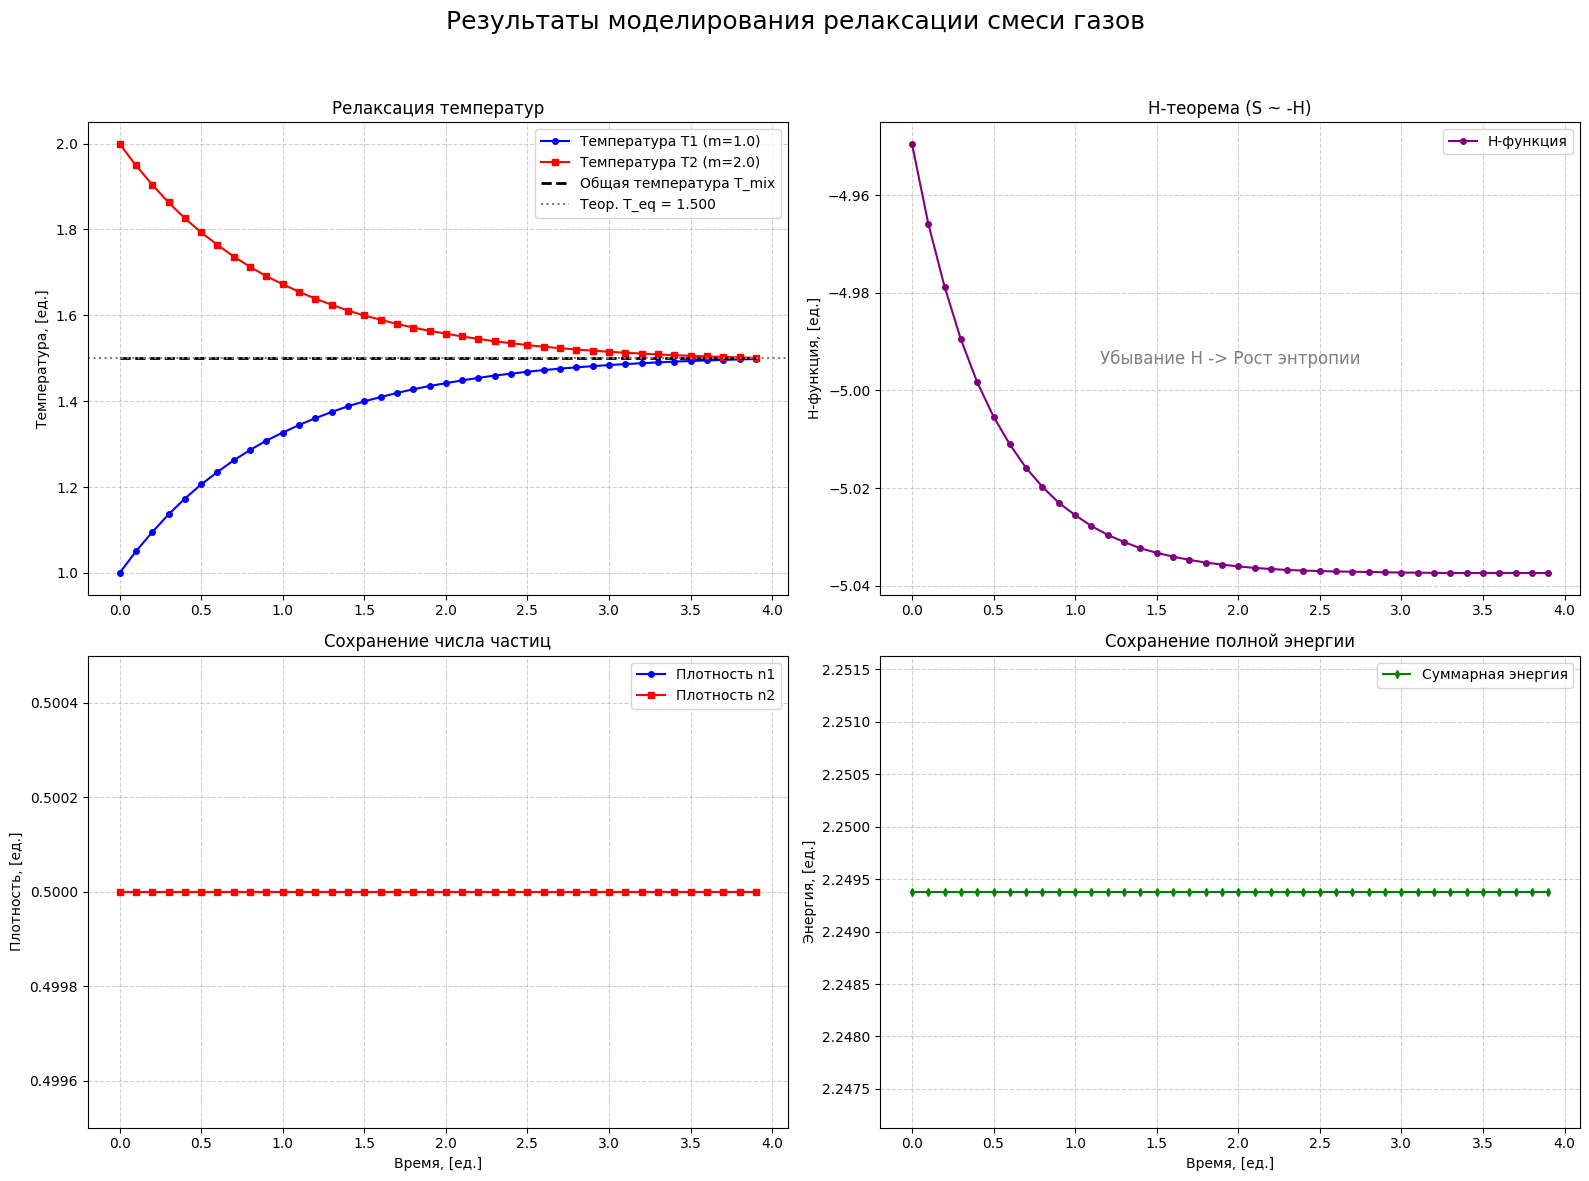

In [9]:
# import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================================
# БЛОК 0: КОНСТАНТЫ И ПАРАМЕТРЫ МОДЕЛИРОВАНИЯ
# ==============================================================================
m1, T1_init, n1_init, d1 = 1.0, 1.0, 0.5, 1.0
m2, T2_init, n2_init, d2 = 2.0, 2.0, 0.5, 1.2
d12 = (d1 + d2) / 2.0

e_cut = 4.8
N_vx = N_vy = N_vz = 20
N_v_arr = np.array([N_vx, N_vy, N_vz])
dV = (2 * e_cut)**3 / (N_vx * N_vy * N_vz)
h_v = (2 * e_cut) / N_v_arr[0]

N_proj_samples = 20000
dt = 0.1
np.random.seed(42)

# Создаем директорию для сохранения изображений, если ее нет
if not os.path.exists('distribution_plots'):
    os.makedirs('distribution_plots')

# ==============================================================================
# БЛОК 1: ИНИЦИАЛИЗАЦИЯ (без изменений)
# ==============================================================================
def alpha2vel(alpha, e_cut_val, N_v_arr):
    return -e_cut_val + (alpha + 0.5) * 2 * e_cut_val / N_v_arr

def maxwellian_3d(vel_vector, n, m, T):
    vel_sq = np.sum(vel_vector**2)
    coeff = n * (m / (2 * np.pi * T))**1.5
    return coeff * np.exp(-m * vel_sq / (2 * T))

def initialize_state():
    print("--- Блок 1: Инициализация начального состояния ---")
    f1_arr = np.zeros((N_vx, N_vy, N_vz)); f2_arr = np.zeros((N_vx, N_vy, N_vz))
    vel_grid_full = np.zeros((N_vx, N_vy, N_vz, 3))
    energy_grid_full_1 = np.zeros((N_vx, N_vy, N_vz)); energy_grid_full_2 = np.zeros((N_vx, N_vy, N_vz))
    valid_indices_list = []

    for i in range(N_vx):
        for j in range(N_vy):
            for k in range(N_vz):
                alpha = np.array([i, j, k]); vel = alpha2vel(alpha, e_cut, N_v_arr)
                vel_grid_full[i, j, k] = vel; vel_sq = np.sum(vel**2)
                energy_grid_full_1[i, j, k] = 0.5 * m1 * vel_sq
                energy_grid_full_2[i, j, k] = 0.5 * m2 * vel_sq

                if vel_sq <= e_cut**2:
                    f1_arr[i, j, k] = maxwellian_3d(vel, n1_init, m1, T1_init)
                    f2_arr[i, j, k] = maxwellian_3d(vel, n2_init, m2, T2_init)
                    valid_indices_list.append(alpha)

    valid_indices = np.array(valid_indices_list)
    f1_arr *= (n1_init / (np.sum(f1_arr) * dV)); f2_arr *= (n2_init / (np.sum(f2_arr) * dV))
    print("--- Инициализация и нормализация завершены ---\n")
    return f1_arr, f2_arr, vel_grid_full, energy_grid_full_1, energy_grid_full_2, valid_indices

# ==============================================================================
# БЛОК 2: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (без изменений)
# ==============================================================================
# ==============================================================================
# БЛОК 2: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (ФИНАЛЬНАЯ ВЕРСИЯ)
# ==============================================================================
def calculate_post_collision_velocities(xi1, xi2, m1_loc, m2_loc):
    m_total = m1_loc + m2_loc
    xi_c = (m1_loc * xi1 + m2_loc * xi2) / m_total
    g = xi2 - xi1
    g_magnitude = np.linalg.norm(g)
    
    # Если скорости почти одинаковы, столкновения нет
    if g_magnitude < 1e-12: 
        return xi1, xi2
        
    # Генерируем случайное направление для относительной скорости после столкновения
    random_direction_vector = np.random.randn(3)
    k = random_direction_vector / np.linalg.norm(random_direction_vector)
    
    g_prime = g_magnitude * k
    
    # Возвращаем новые скорости. Теперь функция всегда возвращает 2 значения.
    return xi_c - (m2_loc / m_total) * g_prime, xi_c + (m1_loc / m_total) * g_prime

def get_interpolation_data(v_prime, m, E_grid):
    """
    Возвращает данные для интерполяции ОДНОЙ частицы.
    Выход: (узел1, узел2, коэфф_интерполяции_r) или None
    """
    if np.sum(v_prime**2) > e_cut**2: return None

    float_indices = (v_prime + e_cut) / h_v - 0.5
    base_indices = np.floor(float_indices).astype(int)
    if np.any(base_indices < 0) or np.any(base_indices + 1 >= N_v_arr): return None

    # Находим 8 узлов-соседей
    nodes, energies = [], []
    for i in range(2):
        for j in range(2):
            for k in range(2):
                idx = tuple(base_indices + np.array([i, j, k]))
                nodes.append(idx)
                energies.append(E_grid[idx])

    E_prime = 0.5 * m * np.sum(v_prime**2)
    E_min, E_max = min(energies), max(energies)
    
    idx1 = nodes[np.argmin(energies)]
    idx2 = nodes[np.argmax(energies)]
    
    delta_E = E_max - E_min
    if delta_E < 1e-14:
        r = 0.0
    else:
        r = (E_prime - E_min) / delta_E
    
    # r - вес для узла с большей энергией (idx2)
    return idx1, idx2, np.clip(r, 0, 1)

def get_joint_conservative_interpolation(v_a_prime, v_b_prime, m_a, m_b, E_grid_a, E_grid_b):
    if np.sum(v_a_prime**2) > e_cut**2 or np.sum(v_b_prime**2) > e_cut**2: return None
    nodes_a_cand = []; nodes_b_cand = []
    for v_prime, nodes_cand in [(v_a_prime, nodes_a_cand), (v_b_prime, nodes_b_cand)]:
        float_indices = (v_prime + e_cut) / h_v - 0.5
        base_indices = np.floor(float_indices).astype(int)
        if np.any(base_indices < 0) or np.any(base_indices + 1 >= N_v_arr): return None
        for i in range(2):
            for j in range(2):
                for k in range(2):
                    nodes_cand.append(tuple(base_indices + np.array([i, j, k])))
    nodes_a_cand.sort(key=lambda idx: E_grid_a[idx])
    lambda1, lambda2 = nodes_a_cand[0], nodes_a_cand[-1]
    nodes_b_cand.sort(key=lambda idx: E_grid_b[idx])
    mu1, mu2 = nodes_b_cand[0], nodes_b_cand[-1]
    system_states = [
        {'E': E_grid_a[lambda1] + E_grid_b[mu1], 'idx_a': lambda1, 'idx_b': mu1},
        {'E': E_grid_a[lambda1] + E_grid_b[mu2], 'idx_a': lambda1, 'idx_b': mu2},
        {'E': E_grid_a[lambda2] + E_grid_b[mu1], 'idx_a': lambda2, 'idx_b': mu1},
        {'E': E_grid_a[lambda2] + E_grid_b[mu2], 'idx_a': lambda2, 'idx_b': mu2},
    ]
    system_states.sort(key=lambda x: x['E'])
    E_total_prime = 0.5 * m_a * np.sum(v_a_prime**2) + 0.5 * m_b * np.sum(v_b_prime**2)
    S_lower, S_upper = None, None
    for i in range(len(system_states) - 1):
        if system_states[i]['E'] <= E_total_prime < system_states[i+1]['E']:
            S_lower, S_upper = system_states[i], system_states[i+1]
            break
    if S_lower is None: S_lower = S_upper = system_states[0] if E_total_prime < system_states[0]['E'] else system_states[-1]
    E_diff = S_upper['E'] - S_lower['E']
    r = (E_total_prime - S_lower['E']) / E_diff if E_diff > 1e-14 else 0.0
    return S_lower, S_upper, np.clip(r, 0, 1)

# ==============================================================================
# БЛОК 3: РАСЧЕТ МАКРОПАРАМЕТРОВ И H-ФУНКЦИИ (без изменений)
# ==============================================================================
def calculate_macroparameters(f_arr, m, vel_grid, E_grid, dV):
    n = np.sum(f_arr) * dV
    if n < 1e-12: return 0, np.zeros(3), 0, 0
    # Импульс равен нулю из-за симметрии начальных условий, не считаем
    E = np.sum(f_arr * E_grid) * dV
    # Так как система в покое, полная кинетическая энергия равна тепловой
    T = (2.0 / 3.0) * E / n if n > 0 else 0
    return n, E, T

def calculate_h_function(f1_arr, f2_arr, dV):
    """Вычисляет H-функцию Больцмана для смеси газов."""
    # Используем маску, чтобы избежать log(0)
    f1_positive = f1_arr[f1_arr > 1e-20]
    f2_positive = f2_arr[f2_arr > 1e-20]
    h1 = np.sum(f1_positive * np.log(f1_positive)) * dV
    h2 = np.sum(f2_positive * np.log(f2_positive)) * dV
    return h1 + h2

# ==============================================================================
# БЛОК 4: РАСЧЕТ ИНТЕГРАЛОВ СТОЛКНОВЕНИЙ (ИСПРАВЛЕН)
# ==============================================================================
# ==============================================================================
# БЛОК 4: РАСЧЕТ ИНТЕГРАЛОВ СТОЛКНОВЕНИЙ (ФИНАЛЬНАЯ ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ==============================================================================
# ==============================================================================
# БЛОК 4: РАСЧЕТ ИНТЕГРАЛОВ СТОЛКНОВЕНИЙ (ФИНАЛЬНАЯ ВЕРСИЯ)
# ==============================================================================
# ==============================================================================
# БЛОК 4: РАСЧЕТ ИНТЕГРАЛОВ СТОЛКНОВЕНИЙ (ФИНАЛЬНАЯ ВЕРСИЯ)
# ==============================================================================
def compute_collision_integrals_projection(f1, f2, m1, m2, d1, d2, d12, vel_grid, E_grid1, E_grid2, N_samples):
    J11, J22, J12, J21 = (np.zeros_like(f1) for _ in range(4))
    num_valid_nodes = len(valid_indices)
    if num_valid_nodes < 2: return J11, J22, J12, J21
    
    alpha_indices = np.random.randint(0, num_valid_nodes, size=N_samples)
    beta_indices = np.random.randint(0, num_valid_nodes, size=N_samples)
    
    prefactor = (num_valid_nodes * dV)**2 / N_samples

    for i in range(N_samples):
        idx_a = tuple(valid_indices[alpha_indices[i]])
        idx_b = tuple(valid_indices[beta_indices[i]])

        if idx_a == idx_b: continue
        
        v_a, v_b = vel_grid[idx_a], vel_grid[idx_b]
        
        # --- Столкновения типа 1-1 (самостолкновения) ---
        v_a_p, v_b_p = calculate_post_collision_velocities(v_a, v_b, m1, m1)
        g_norm = np.linalg.norm(v_a - v_b) # g_norm вычисляется здесь
        
        interp_data = get_joint_conservative_interpolation(v_a_p, v_b_p, m1, m1, E_grid1, E_grid1)
        if interp_data:
            S_l, S_u, r = interp_data
            f_p_prod = (1 - r) * (f1[S_l['idx_a']] * f1[S_l['idx_b']]) + r * (f1[S_u['idx_a']] * f1[S_u['idx_b']])
            f_pre_prod = f1[idx_a] * f1[idx_b]
            
            # === КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ: Фактор 1/2 для неразличимых частиц ===
            omega = 0.5 * (f_pre_prod - f_p_prod) * g_norm * (np.pi * d1**2) * prefactor
            
            J11[idx_a] -= omega
            J11[idx_b] -= omega
            J11[S_l['idx_a']] += omega * (1 - r)
            J11[S_l['idx_b']] += omega * (1 - r)
            J11[S_u['idx_a']] += omega * r
            J11[S_u['idx_b']] += omega * r
            
        # --- Столкновения типа 2-2 (самостолкновения) ---
        v_a_p, v_b_p = calculate_post_collision_velocities(v_a, v_b, m2, m2)
        g_norm = np.linalg.norm(v_a - v_b) # g_norm вычисляется здесь
        
        interp_data = get_joint_conservative_interpolation(v_a_p, v_b_p, m2, m2, E_grid2, E_grid2)
        if interp_data:
            S_l, S_u, r = interp_data
            f_p_prod = (1 - r) * (f2[S_l['idx_a']] * f2[S_l['idx_b']]) + r * (f2[S_u['idx_a']] * f2[S_u['idx_b']])
            f_pre_prod = f2[idx_a] * f2[idx_b]

            # === КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ: Фактор 1/2 для неразличимых частиц ===
            omega = 0.5 * (f_pre_prod - f_p_prod) * g_norm * (np.pi * d2**2) * prefactor

            J22[idx_a] -= omega
            J22[idx_b] -= omega
            J22[S_l['idx_a']] += omega * (1 - r)
            J22[S_l['idx_b']] += omega * (1 - r)
            J22[S_u['idx_a']] += omega * r
            J22[S_u['idx_b']] += omega * r

        # --- Столкновения типа 1-2 (межсортовые) ---
        v_a_p, v_b_p = calculate_post_collision_velocities(v_a, v_b, m1, m2)
        g_norm = np.linalg.norm(v_a - v_b) # g_norm вычисляется здесь

        interp_data = get_joint_conservative_interpolation(v_a_p, v_b_p, m1, m2, E_grid1, E_grid2)
        if interp_data:
            S_l, S_u, r = interp_data
            f_p_prod = (1 - r) * (f1[S_l['idx_a']] * f2[S_l['idx_b']]) + r * (f1[S_u['idx_a']] * f2[S_u['idx_b']])
            f_pre_prod = f1[idx_a] * f2[idx_b]

            # НЕТ фактора 0.5 для различимых частиц
            omega = (f_pre_prod - f_p_prod) * g_norm * (np.pi * d12**2) * prefactor
            
            J12[idx_a] -= omega
            J21[idx_b] -= omega
            J12[S_l['idx_a']] += omega * (1 - r)
            J21[S_l['idx_b']] += omega * (1 - r)
            J12[S_u['idx_a']] += omega * r
            J21[S_u['idx_b']] += omega * r

    return J11, J22, J12, J21

# ==============================================================================
# БЛОК 5: ПОСТРОЕНИЕ ГРАФИКОВ (без изменений)
# ==============================================================================
def plot_macro_parameters(history):
    """Строит графики изменения макропараметров и H-функции во времени."""
    time_hist = history['t']
    T1_hist, T2_hist, T_total_hist = history['T1'], history['T2'], history['T_total']
    n1_hist, n2_hist = history['n1'], history['n2']
    
    # === ИСПРАВЛЕНИЕ ЗДЕСЬ ===
    # Извлекаем данные из правильных ключей словаря
    E_total_hist = history['E_tot'] 
    H_hist = history['H']
    # ==========================

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Результаты моделирования релаксации смеси газов', fontsize=18)
    
    # 1. Температуры
    ax1 = axes[0, 0]
    ax1.plot(time_hist, T1_hist, 'o-', label=f'Температура T1 (m={m1})', color='blue', markersize=4)
    ax1.plot(time_hist, T2_hist, 's-', label=f'Температура T2 (m={m2})', color='red', markersize=4)
    ax1.plot(time_hist, T_total_hist, '--', label='Общая температура T_mix', color='black', lw=2)
    T_eq = (n1_init * T1_init + n2_init * T2_init) / (n1_init + n2_init)
    ax1.axhline(y=T_eq, color='gray', linestyle=':', label=f'Теор. T_eq = {T_eq:.3f}')
    ax1.set_ylabel('Температура, [ед.]'); ax1.set_title('Релаксация температур'); ax1.grid(True, ls='--', alpha=0.6); ax1.legend()

    # 2. H-функция (Энтропия)
    ax2 = axes[0, 1]
    ax2.plot(time_hist, H_hist, 'o-', label='H-функция', color='purple', markersize=4)
    ax2.set_ylabel('H-функция, [ед.]'); ax2.set_title('H-теорема (S ~ -H)'); ax2.grid(True, ls='--', alpha=0.6); ax2.legend()
    ax2.text(0.5, 0.5, 'Убывание H -> Рост энтропии', transform=ax2.transAxes,
             fontsize=12, ha='center', va='center', alpha=0.5)

    # 3. Плотности
    ax3 = axes[1, 0]
    ax3.plot(time_hist, n1_hist, 'o-', label=f'Плотность n1', color='blue', markersize=4)
    ax3.plot(time_hist, n2_hist, 's-', label=f'Плотность n2', color='red', markersize=4)
    ax3.set_xlabel('Время, [ед.]'); ax3.set_ylabel('Плотность, [ед.]'); ax3.set_title('Сохранение числа частиц')
    ax3.set_ylim(min(n1_init, n2_init) * 0.999, max(n1_init, n2_init) * 1.001)
    ax3.grid(True, ls='--', alpha=0.6); ax3.legend()

    # 4. Энергия
    ax4 = axes[1, 1]
    ax4.plot(time_hist, E_total_hist, 'd-', label='Суммарная энергия', color='green', markersize=4)
    ax4.set_xlabel('Время, [ед.]'); ax4.set_ylabel('Энергия, [ед.]'); ax4.set_title('Сохранение полной энергии')
    # Добавим проверку, что история не пуста, перед доступом к элементу
    if E_total_hist:
        ax4.set_ylim(E_total_hist[0] * 0.999, E_total_hist[0] * 1.001)
    ax4.grid(True, ls='--', alpha=0.6); ax4.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('macro_parameters_evolution_FIXED.png', dpi=300)
    plt.show()

def plot_distribution_slice(f1_arr, f2_arr, time, step_idx):
    """Строит срез функции распределения по v_z=0."""
    slice_idx = N_vz // 2
    f1_slice = f1_arr[:, :, slice_idx]
    f2_slice = f2_arr[:, :, slice_idx]
    v_coords = -e_cut + (np.arange(N_vx) + 0.5) * h_v
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Срез функции распределения f(v_x, v_y, v_z=0) в момент времени t = {time:.2f}', fontsize=16)
    vmax = max(f1_slice.max(), f2_slice.max()) * 1.1
    im1 = axes[0].pcolormesh(v_coords, v_coords, f1_slice.T, shading='auto', cmap='viridis', vmin=0, vmax=vmax)
    axes[0].set_title(f'Газ 1 (m={m1}, T_init={T1_init})'); axes[0].set_xlabel('Скорость v_x'); axes[0].set_ylabel('Скорость v_y'); axes[0].set_aspect('equal', 'box')
    fig.colorbar(im1, ax=axes[0], label='f1')
    im2 = axes[1].pcolormesh(v_coords, v_coords, f2_slice.T, shading='auto', cmap='viridis', vmin=0, vmax=vmax)
    axes[1].set_title(f'Газ 2 (m={m2}, T_init={T2_init})'); axes[1].set_xlabel('Скорость v_x'); axes[1].set_ylabel('Скорость v_y'); axes[1].set_aspect('equal', 'box')
    fig.colorbar(im2, ax=axes[1], label='f2')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(f'distribution_plots/distribution_slice_{step_idx:03d}.png', dpi=150)
    plt.close(fig)

# ==============================================================================
# БЛОК 6: ГЛАВНЫЙ СКРИПТ СИМУЛЯЦИИ (без изменений)
# ==============================================================================
if __name__ == "__main__":
    num_steps = 40
    f1_arr, f2_arr, vel_grid, E_grid1, E_grid2, valid_indices = initialize_state()
    history = {'t':[], 'n1':[], 'n2':[], 'T1':[], 'T2':[], 'T_total': [], 'E_tot':[], 'H':[]}
    plot_steps = [0, num_steps // 3, num_steps - 1]

    def get_rhs(f1, f2):
        J11, J22, J12, J21 = compute_collision_integrals_projection(
            f1, f2, m1, m2, d1, d2, d12, vel_grid, E_grid1, E_grid2, N_proj_samples
        )
        return (J11 + J12), (J22 + J21)

    for step in range(num_steps):
        n1, E1, T1 = calculate_macroparameters(f1_arr, m1, vel_grid, E_grid1, dV)
        n2, E2, T2 = calculate_macroparameters(f2_arr, m2, vel_grid, E_grid2, dV)
        E_total = E1 + E2
        T_total = (2.0 / 3.0) * E_total / (n1 + n2) if (n1+n2)>0 else 0
        H_total = calculate_h_function(f1_arr, f2_arr, dV)
        
        current_time = step * dt
        history['t'].append(current_time); history['n1'].append(n1); history['n2'].append(n2)
        history['T1'].append(T1); history['T2'].append(T2); history['T_total'].append(T_total)
        history['E_tot'].append(E_total); history['H'].append(H_total)

        print(f"Шаг {step:>2}/{num_steps} | Время: {current_time:.2f} | T1={T1:.3f} | T2={T2:.3f} | T_mix={T_total:.3f} | H={H_total:.3f}")

        if step in plot_steps:
            print(f"--- Создание среза функции распределения на шаге {step} ---")
            plot_distribution_slice(f1_arr, f2_arr, current_time, step)

        if step == num_steps -1: break

        J1_k1, J2_k1 = get_rhs(f1_arr, f2_arr)
        f1_k2_in = f1_arr + 0.5 * dt * J1_k1; f2_k2_in = f2_arr + 0.5 * dt * J2_k1
        J1_k2, J2_k2 = get_rhs(f1_k2_in, f2_k2_in)
        f1_k3_in = f1_arr + 0.5 * dt * J1_k2; f2_k3_in = f2_arr + 0.5 * dt * J2_k2
        J1_k3, J2_k3 = get_rhs(f1_k3_in, f2_k3_in)
        f1_k4_in = f1_arr + dt * J1_k3; f2_k4_in = f2_arr + dt * J2_k3
        J1_k4, J2_k4 = get_rhs(f1_k4_in, f2_k4_in)
        
        f1_arr += (dt / 6.0) * (J1_k1 + 2*J1_k2 + 2*J1_k3 + J1_k4)
        f2_arr += (dt / 6.0) * (J2_k1 + 2*J2_k2 + 2*J2_k3 + J2_k4)

    print("\n" + "="*50); print("СИМУЛЯЦИЯ ЗАВЕРШЕНА"); print("="*50)
    print("Изображения срезов сохранены в папке 'distribution_plots/'")
    print("Построение итоговых графиков...")
    plot_macro_parameters(history)